
--- 1. Análisis Exploratorio de Datos (EDA) ---


Primeras 5 filas:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 

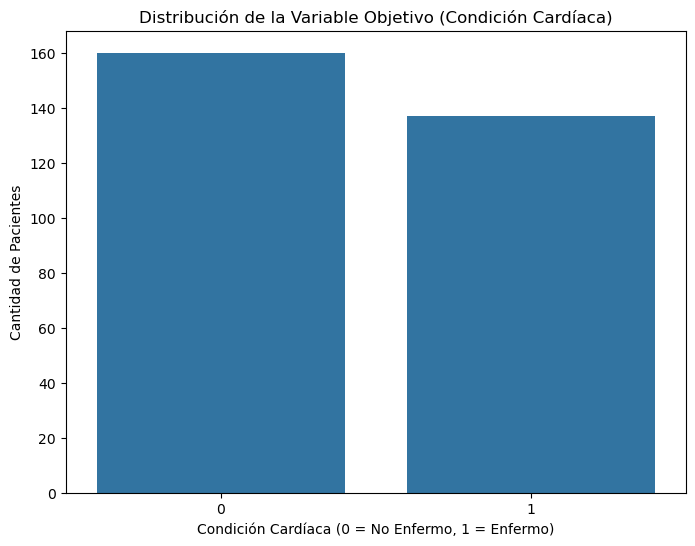

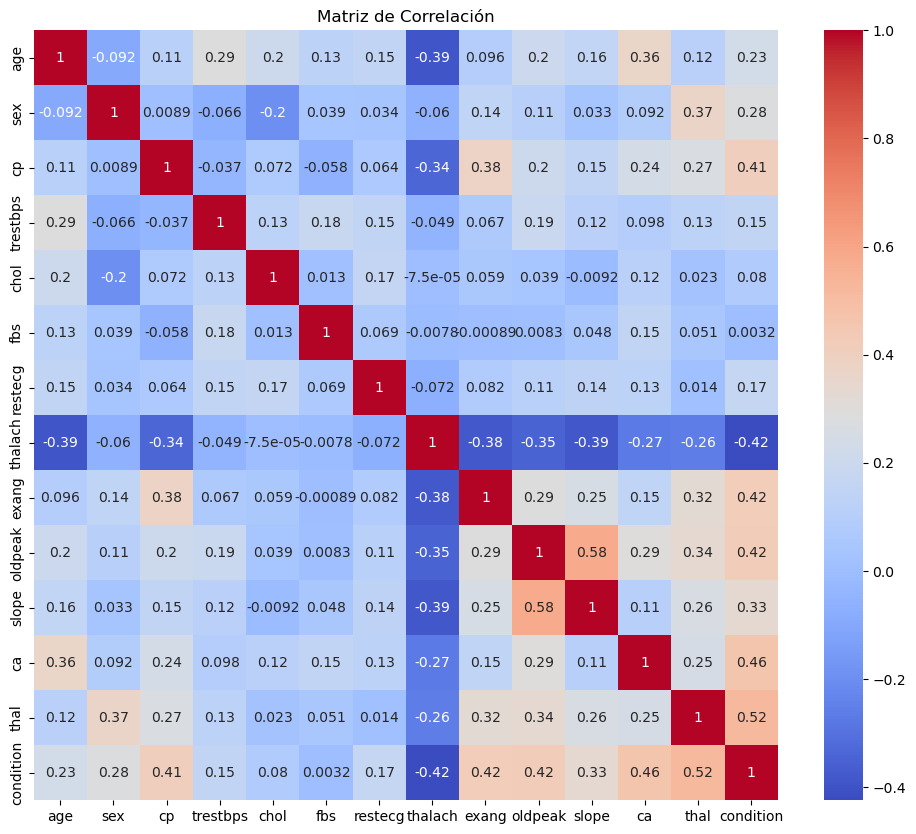

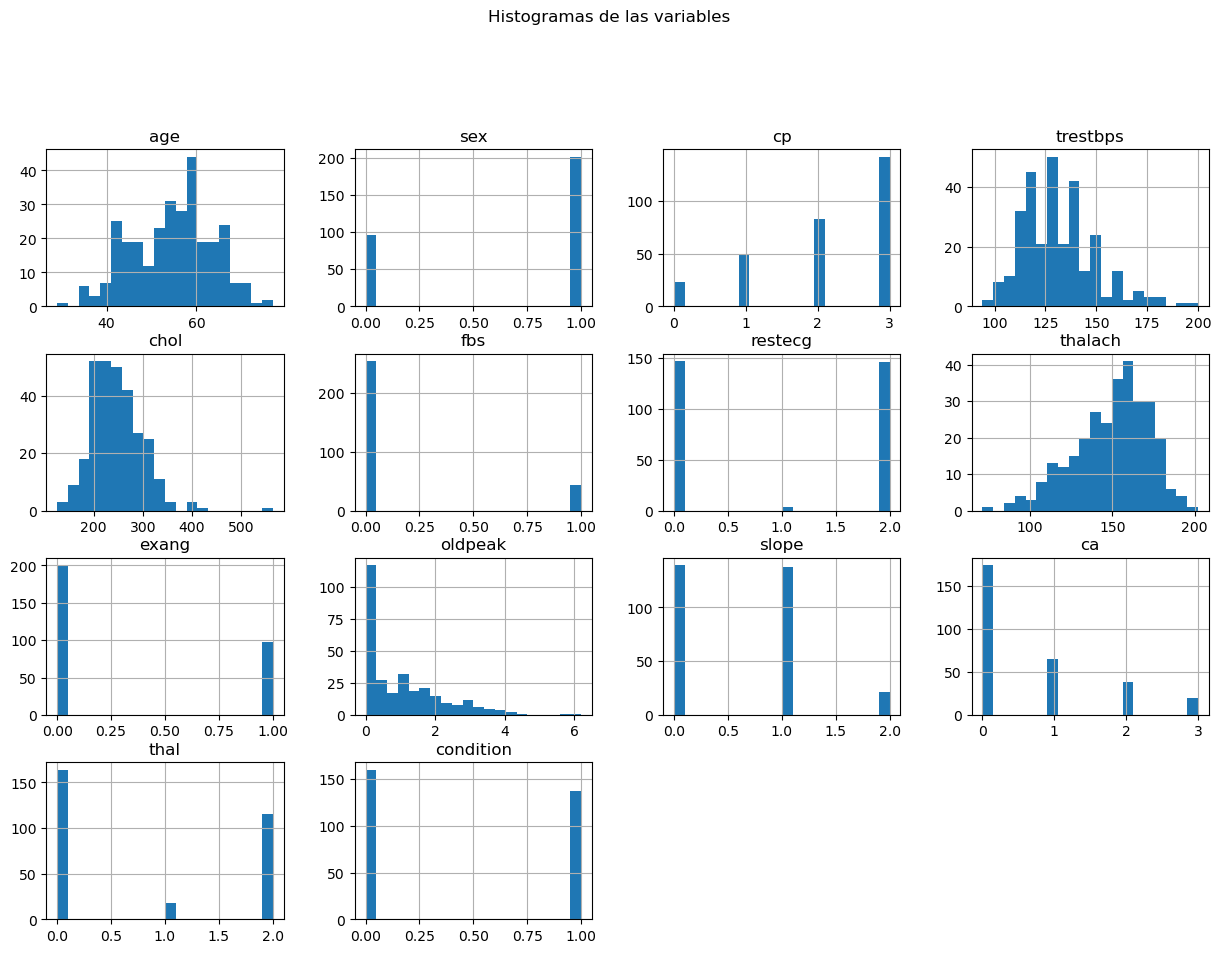


--- 2. Preprocesamiento de los datos ---


Valores faltantes por columna:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Valores faltantes después de eliminar:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

Columnas categóricas:
 []

--- 3. Selección de características ---


Características seleccionadas:
 ['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

--- 4. Dividir el dataset en Train y Test ---


--- 5. Entrenar el modelo ---

Mejores hiperparámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

--- 6. Evaluar el desempeño del modelo ---


Matriz de Confusión:
 [[25  7]
 [ 7 21]]

In

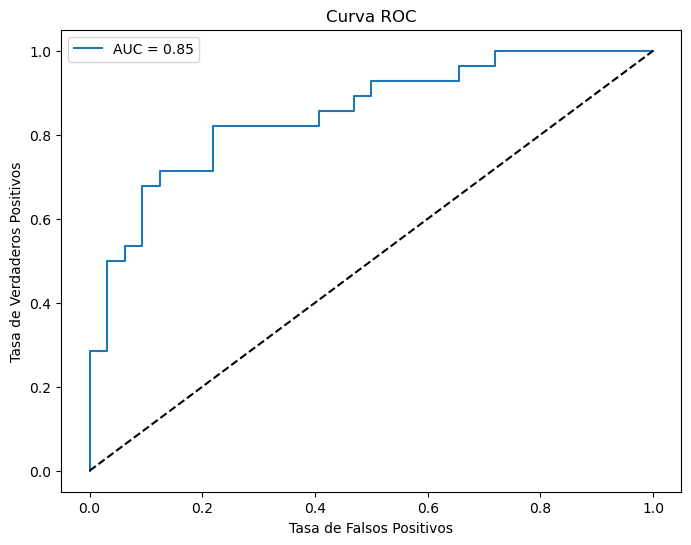

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.feature_selection import SelectKBest, chi2

# 1. Cargar el dataset
file_path = 'regresionlogistica/heart_cleveland_upload.csv'  # Asegúrate que la ruta es correcta
df = pd.read_csv(file_path)

# 1. Análisis Exploratorio de Datos (EDA)
print("\n--- 1. Análisis Exploratorio de Datos (EDA) ---\n")

# 1.1 Primeras filas del dataset
print("\nPrimeras 5 filas:\n", df.head())

# 1.2 Información del dataset
print("\nInformación del dataset:\n")
df.info()

# 1.3 Descripción estadística del dataset
print("\nDescripción estadística:\n", df.describe())

# 1.4 Distribución de la variable objetivo 'condition'
plt.figure(figsize=(8, 6))
sns.countplot(x='condition', data=df)
plt.title('Distribución de la Variable Objetivo (Condición Cardíaca)')
plt.xlabel('Condición Cardíaca (0 = No Enfermo, 1 = Enfermo)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

# 1.5 Matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# 1.6 Histograma de las variables
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histogramas de las variables", y=1.02)
plt.show()

# 2. Preprocesamiento de los datos
print("\n--- 2. Preprocesamiento de los datos ---\n")

# 2.1 Verificar si hay valores faltantes
print("\nValores faltantes por columna:\n", df.isnull().sum())

# 2.2 Manejar valores faltantes (si los hay)
df = df.dropna()  # Eliminar filas con valores faltantes (o imputar si es necesario)
print("\nValores faltantes después de eliminar:\n", df.isnull().sum())

# 2.3 Identificar y manejar variables categóricas
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
print("\nColumnas categóricas:\n", categorical_cols)

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # One-Hot Encode
    print("\nDataFrame después del One-Hot Encoding:\n", df.head())

# 3. Selección de características
print("\n--- 3. Selección de características ---\n")

X = df.drop('condition', axis=1, errors='ignore') # features, errors='ignore' evita error si no encuentra la columna
y = df['condition']   # target

# Verificar si hay suficientes características para seleccionar
if X.shape[1] > 1:
    selector = SelectKBest(score_func=chi2, k=min(10, X.shape[1]))  # Selecciona las mejores k características
    selector.fit(X, y)
    X_selected = X.columns[selector.get_support(indices=True)].tolist()
    print("\nCaracterísticas seleccionadas:\n", X_selected)
    X = df[X_selected]
else:
    print("\nNo hay suficientes características para la selección. Se usarán todas.\n")

# 4. Dividir el dataset en Train y Test
print("\n--- 4. Dividir el dataset en Train y Test ---\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenar el modelo
print("\n--- 5. Entrenar el modelo ---\n")

# 5.1 Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5.2 Usar GridSearch para encontrar los mejores hiperparámetros
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# 6. Evaluar el desempeño del modelo
print("\n--- 6. Evaluar el desempeño del modelo ---\n")

y_pred = best_model.predict(X_test_scaled)

print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nInforme de Clasificación:\n", classification_report(y_test, y_pred))

# 7. Visualizar los resultados
print("\n--- 7. Visualizar los resultados ---\n")

# 7.1 Curva ROC y AUC
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()
